# Importing Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install wordcloud

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,precision_score
import re
import string
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier

In [4]:
data_fake=pd.read_csv(r"C:\Users\User\Downloads\Fake.csv",encoding="ISO-8859-1")

In [5]:
data_fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied âSafe Zoneâ Plan ...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [6]:
data_fake.head(3)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


In [7]:
data_fake.shape

(23481, 4)

In [8]:
data_true=pd.read_csv(r"C:\Users\User\Downloads\True.csv",encoding="ISO-8859-1")

In [9]:
data_true

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [10]:
data_true.head(3)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"


In [11]:
data_true.shape

(21417, 4)

#  Loading Datasets

In [12]:
data_fake.tail()

,title,text,subject,date
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied âSafe Zoneâ Plan ...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016"


In [13]:
data_fake['class']=0
data_fake

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied âSafe Zoneâ Plan ...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [14]:
data_fake.tail()

,title,text,subject,date,class
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied âSafe Zoneâ Plan ...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


#  Creating Dataset for Model Building

In [15]:
data_true['class']=1
data_true

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [16]:
data_fake.shape,data_true.shape

((23481, 5), (21417, 5))

In [17]:
data_merge=pd.concat([data_fake,data_true],axis=0)
data_merge

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [18]:
data_merge.shape

(44898, 5)

In [19]:
data_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [20]:
data=data_merge.drop(['title','subject','date'],axis=1)                                                      

In [21]:
data.isnull().sum()

text     0
class    0
dtype: int64

In [22]:
data=data.sample(frac=1)  #randomly picking data in 1D

In [23]:
data.head()

,text,class
13751,Bernie Sanders likes to talk about how everyon...,0
5589,"Don Christy, who claims he s neither a Republi...",0
1125,WASHINGTON/NEW YORK (Reuters) - The Trump admi...,1
8030,WASHINGTON (Reuters) - Democrat Hillary Clinto...,1
17731,"Earlier today, the disgraced former host of MS...",0


In [24]:
data.to_csv('datas')

In [25]:
data.reset_index(inplace=True)
data.head(3)

,index,text,class
0,13751,Bernie Sanders likes to talk about how everyon...,0
1,5589,"Don Christy, who claims he s neither a Republi...",0
2,1125,WASHINGTON/NEW YORK (Reuters) - The Trump admi...,1


In [26]:
data.drop(['index'],axis=1,inplace=True)

#  EDA

In [27]:
data.columns

Index(['text', 'class'], dtype='object')

In [28]:
data.head()

,text,class
0,Bernie Sanders likes to talk about how everyon...,0
1,"Don Christy, who claims he s neither a Republi...",0
2,WASHINGTON/NEW YORK (Reuters) - The Trump admi...,1
3,WASHINGTON (Reuters) - Democrat Hillary Clinto...,1
4,"Earlier today, the disgraced former host of MS...",0


In [29]:
data.shape

(44898, 2)

In [30]:
data.describe()

,class
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [31]:
data.isnull().sum()

text     0
class    0
dtype: int64

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   class   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


#  Preprocessing Text Data

In [33]:
def wordopt(text): #creating function to process text
    text=text.lower()
    text=re.sub('\[.*?\]','',text)
    text=re.sub("\\W"," ",text)
    text=re.sub('https?://\S+|www\.\S+','',text)
    text=re.sub('<.*?>+','',text)
    text=re.sub('[%s]'% re.escape(string.punctuation),'',text)
    text=re.sub('\n','',text)
    text=re.sub('\w*\d\w*','',text)
    return text

In [34]:
data['text']=data['text'].apply(wordopt)

#  Data Visualization

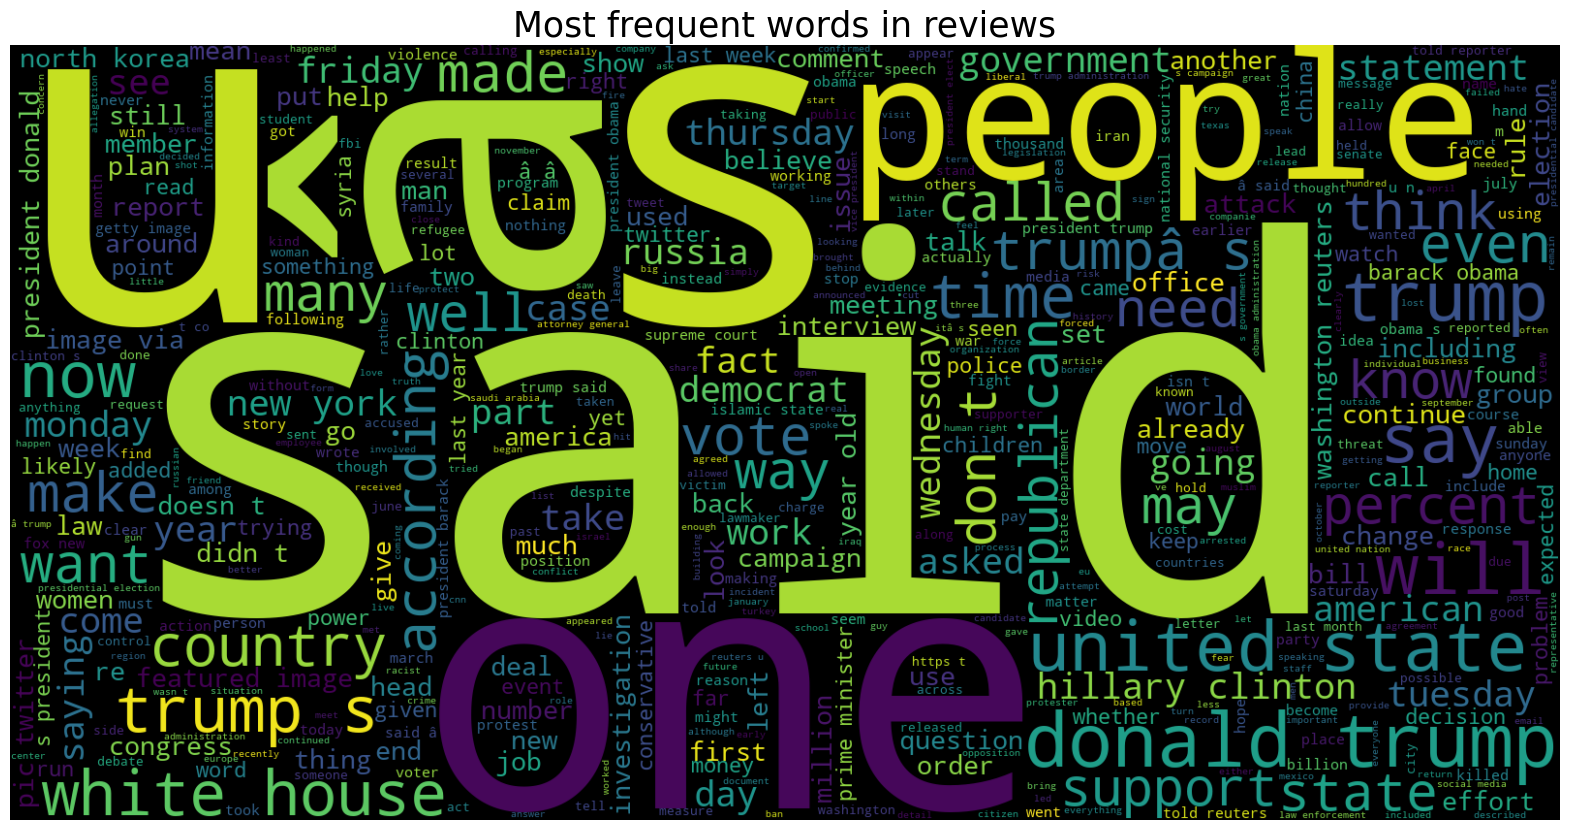

In [35]:
text=' '.join([word for word in data['text']])
plt.figure(figsize=(20,15),facecolor='None')
wordcloud=WordCloud(max_words=500,width=1600,height=800).generate(text)
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in reviews', fontsize=25)
plt.show()

#  Data Splitting

In [36]:
x=data['text']
y=data['class']

In [37]:
x

0        bernie sanders likes to talk about how everyon...
1        don christy  who claims he s neither a republi...
2        washington new york  reuters    the trump admi...
3        washington  reuters    democrat hillary clinto...
4        earlier today  the disgraced former host of ms...
                               ...                        
44893    student government leaders at loyola universit...
44894    during his presidential campaign  donald trump...
44895    washington  reuters    it will be a new day at...
44896    harvey weinstein was among a host of hollywood...
44897    the lefty lunatic of the day just can t keep h...
Name: text, Length: 44898, dtype: object

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [39]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(33673,) (11225,) (33673,) (11225,)


#  NLP

In [40]:
vectorization=TfidfVectorizer()
xv_train=vectorization.fit_transform(x_train)
xv_test=vectorization.transform(x_test)

In [41]:
xv_train

<33673x101379 sparse matrix of type '<class 'numpy.float64'>'
	with 6936723 stored elements in Compressed Sparse Row format>

In [42]:
xv_train.shape

(33673, 101379)

In [46]:
xv_test.shape

(11225, 101379)

#  Model Building

### Logistic Regression 

In [44]:
LR=LogisticRegression()
LR.fit(xv_train,y_train)

LogisticRegression()

In [45]:
pred_lr1=LR.predict(xv_test)
pred_lr1

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [47]:
LR_acc=LR.score(xv_test,y_test)
LR_acc

0.9890423162583519

In [48]:
print(classification_report(y_test,pred_lr1))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5862
           1       0.99      0.99      0.99      5363

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



### Decision Tree Classifier

In [49]:
DT=DecisionTreeClassifier()
DT.fit(xv_train,y_train)

DecisionTreeClassifier()

In [50]:
pred_dt1=DT.predict(xv_test)
pred_dt1

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [51]:
pred_dt2=DT.predict(xv_train)
pred_dt2

array([1, 1, 0, ..., 0, 0, 1], dtype=int64)

In [52]:
DT_acc=accuracy_score(y_test,pred_dt1)
DT_acc

0.9967037861915368

In [53]:
precision_score(y_test,pred_dt1)

0.9979431563201197

###  Gradient Boosting Classifier

In [54]:
GB=GradientBoostingClassifier()
GB.fit(xv_train,y_train)

GradientBoostingClassifier()

In [58]:
pred_gb=GB.predict(xv_test)
pred_gb

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [59]:
y_test

22216    0
27917    0
25007    0
1377     0
32476    1
        ..
15578    1
29394    0
3120     0
25388    1
14337    0
Name: class, Length: 11225, dtype: int64

In [60]:
GB_acc=accuracy_score(y_test,pred_gb)
GB_acc

0.9958129175946547

In [61]:
print(classification_report(y_test,pred_gb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5862
           1       0.99      1.00      1.00      5363

    accuracy                           1.00     11225
   macro avg       1.00      1.00      1.00     11225
weighted avg       1.00      1.00      1.00     11225



### Random Forest Classifier 

In [62]:
RF=RandomForestClassifier(random_state=0)
RF.fit(xv_train,y_train)

RandomForestClassifier(random_state=0)

In [63]:
pred_rf=RF.predict(xv_test)

In [64]:
RF_acc=RF.score(xv_test,y_test)
RF_acc

0.9941202672605791

In [66]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,pred_rf))

[[5824   38]
 [  28 5335]]


## Performance Analysis on each model 

In [68]:
pt=[]
t=[]
for i in[LR,GB,RF,DT]:
    i.fit(xv_train,y_train)
    pt.append(round(accuracy_score(y_test,i.predict(xv_test))*100,2))
    t.append(round(accuracy_score(y_train,i.predict(xv_train))*100,2))
print(pt)
print(t)

[98.9, 99.6, 99.41, 99.64]
[99.33, 99.74, 100.0, 100.0]
